In [1]:
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt

carpeta_salida_figuras = Path("../Outputs/Figures")
carpeta_salida_figuras.mkdir(parents=True, exist_ok=True)

carpeta_salida_tablas = Path("../Outputs/Tables")
carpeta_salida_tablas.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None) # Maximiza la cantidad de columnas que muestra el dataframe
pd.set_option("display.max_rows", None) # Maximiza la cantidad de filas que muestra el dataframe
pd.set_option("display.max_colwidth", None) # Maximiza la cantidad de información que muestran las celdas del dataframe

df = pd.read_csv(r"../Data/processed/Caracteristicas y composicion del hogar - Filtrado.csv"
                 , sep=",") # ,sep=";" es esencial. Sin ese parámetro el dataset será ilegible.
df.head(5)

,Numero_orden_p_hogar,Tipo_Documento_idetidad,Edad,Parentesco_jefe_hogar,Estado_civil,Étnia,Satisfaccion_vida,Satisfaccion_ingreso,Satisfaccion_salud,Satisfaccion_seguridad,Satisfaccion_trabajo,Satisfaccion_tiempo_libre,Sentido_proposito,Escalera_cantril,Autorreconocimiento_sexual
0,1,3,45,1,5.0,6,8.0,99.0,10.0,10.0,5.0,7.0,7.0,6.0,2.0
1,2,3,25,7,4.0,6,10.0,8.0,10.0,10.0,8.0,7.0,8.0,8.0,1.0
2,1,3,62,1,3.0,6,5.0,4.0,7.0,7.0,4.0,7.0,8.0,7.0,2.0
3,1,3,38,1,2.0,6,8.0,8.0,8.0,5.0,8.0,8.0,8.0,8.0,2.0
4,2,3,49,2,2.0,6,8.0,9.0,8.0,5.0,8.0,8.0,8.0,8.0,1.0


# __Búsqueda de Outliers en la variable edad:__

df.sort_values("averageRating", ascending=False)
Q1 = df["averageRating"].quantile(0.25)
Q3 = df["averageRating"].quantile(0.75)
IQR = Q3 - Q1

# Define limits
lim_inferior = Q1 - 1.5 * IQR
lim_superior = Q3 + 1.5 * IQR

# Outliers filtering 
OutliersGeneral = df[(df["averageRating"] < lim_inferior) | (df["averageRating"] > lim_superior)]
print(OutliersGeneral["averageRating"].head(10))
plt.title("General Outliers", fontsize=16, fontweight='bold')
df.boxplot(column="averageRating")
plt.show()

0    45
1    25
2    62
3    38
4    49
5    62
6    74
7    93
8    43
9    63
Name: Edad, dtype: int64


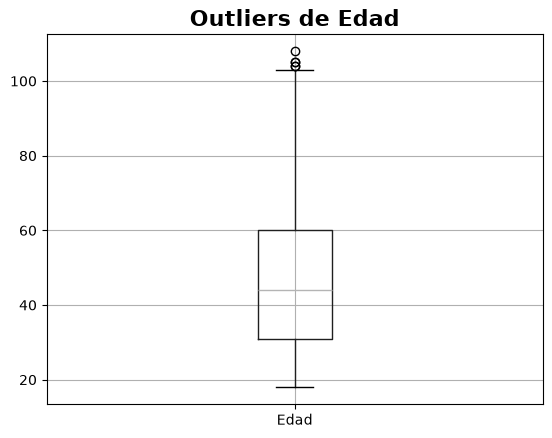

In [4]:
df.sort_values("Edad", ascending=False)
Q1 = df["Edad"].quantile(0.25)
Q3 = df["Edad"].quantile(0.75)
IQR = Q3 - Q1

lim_inferior = Q1 - 1.5 * IQR
lim_superior = Q3 - 1.5 * IQR

OutliersEdad = df[(df["Edad"] < lim_inferior) | (df["Edad"] > lim_superior)]
print(OutliersEdad["Edad"].head(10))
plt.title("Outliers de Edad", fontsize=16, fontweight="bold")
df.boxplot(column="Edad")
plt.show()